<div style="text-align: center">
<img src="https://github.com/LinkedEarth/Logos/blob/master/PyleoTUPS/pyleotups_logo.png?raw=true" alt="PyleoTUPS logo" width="400">
</div>

# Querying the NOAA NCEI Database

## Authors

Deborah Khider [![ORCID](https://img.shields.io/badge/ORCID-0000--0001--7501--8430-A6CE39?logo=orcid)](https://orcid.org/0000-0001-7501-8430), Dhiren Oswal [![ORCID](https://img.shields.io/badge/ORCID-0009--0001--2495--2626-A6CE39?logo=orcid)](https://orcid.org/0009-0001-2495-2626)


## Preamble

In a [previous chapter](02_a_NOAAObject.ipynb), you learned how to create a [`NOAADataset` object](https://pyleotups.readthedocs.io/en/latest/api.html#noaadataset-pyleotups-core-noaadataset-noaadataset) and its many functionalities. We won't be revisiting those here; just know that regardless of how many datasets are returned, the functions will apply. 

This tutorial demonstrates how to query the database. A list of search parameters is available on the [NOAA website](https://www.ncei.noaa.gov/access/paleo-search/api) and is summarized below:

* `xml_id` : str, optional
         Specify the internal XML document ID. Must be an exact match (e.g., '1840').

* `noaa_id` : str, optional
        Provide the unique NOAA Study ID as a number (e.g., '13156').

* `search_text` : str, optional
        General text search across study content. Supports wildcards (%) and logical operators (AND, OR).
        Examples: 'younger dryas', 'loess AND stratigraphy'

* `data_publisher` : by default 'NOAA'
        Choose from: 'NOAA', 'NEOTOMA', or 'PANGAEA'.
        Example: 'NOAA'

* `data_type_id` : str, optional
        Filter by data type. Use one or more type IDs separated by '|'.
        Available IDs:
                1: BOREHOLE, 2: CLIMATE FORCING, 3: CLIMATE RECONSTRUCTIONS, 4: CORALS AND SCLEROSPONGES,
                6: HISTORICAL, 7: ICE CORES, 8: INSECT, 9: LAKE LEVELS, 10: LOESS,
                11: PALEOCLIMATIC MODELING, 12: FIRE HISTORY, 13: PALEOLIMNOLOGY, 14: PALEOCEANOGRAPHY,
                15: PLANT MACROFOSSILS, 16: POLLEN, 17: SPELEOTHEMS, 18: TREE RING,
                19: OTHER COLLECTIONS, 20: INSTRUMENTAL, 59: SOFTWARE, 60: REPOSITORY
        Example: '4', '4|18'

* `investigators` : str or list[str], optional
        Investigator(s) in the form ``"LastName, Initials"``. Lists are joined with ``|``.
        
* `investigators_and_or` : {"and","or"}, default "or"
        Logical combiner when multiple investigators are supplied. Only sent when 2+ items.
        
* `locations` : str or list[str], optional
        Location(s) as hierarchical strings using ``>`` (e.g., ``"Continent>Africa>Kenya"``). Lists joined with ``|``.
        
* `locations_and_or` : {"and","or"}, default "or"
        Logical combiner for multiple locations. Only sent when 2+ items.
        
* `keywords` : str or list[str], optional
        Controlled keyword(s); hierarchies with ``>``. Lists joined with ``|``.
        
* `keywords_and_or` : {"and","or"}, default "or"
        Logical combiner for multiple keywords. Only sent when 2+ items.
        
* `species` : str or list[str], optional
        Four-letter tree species codes (uppercase enforced). Lists joined with ``|``.
        
* `species_and_or` : {"and","or"}, default "or"
        Logical combiner for multiple species. Only sent when 2+ items.
        
* `variable_name` : str or list[str], optional
        Refers to PaST "cvWhats” terms (hierarchies with ``>``). Lists joined with ``|``.
        
* `variable_name_and_or` : {"and","or"}, default "or"
        Logical combiner for multiple cvWhats/variable_name. Only sent when 2+ items.
        
* `cv_materials` : str or list[str], optional
        PaST “Material” terms (hierarchies with ``>``). Lists joined with ``|``.
        
* `cv_materials_and_or` : {"and","or"}, default "or"
        Logical combiner for multiple cv_materials. Only sent when 2+ items.
        
* `cv_seasonalities` : str or list[str], optional
        PaST “Seasonality” terms (e.g., ``"annual"`` or ``"3-month>Aug-Oct"``). Lists joined with ``|``.
        
* `cv_seasonalities_and_or` : {"and","or"}, default "or"
        Logical combiner for multiple cv_seasonalities. Only sent when 2+ items.
        
* `min_lat`, `max_lat` : int, optional
        Latitude bounds in whole degrees (–90..90).
        
* `min_lon`, `max_lon` : int, optional
        Longitude bounds in whole degrees (–180..180).
        
* `min_elevation`, `max_elevation` : int, optional
        Elevation bounds in meters (integers; negative allowed).
        
* `earliest_year`, `latest_year` : int, optional
        Year bounds (integers; negative allowed). If provided without time settings, ``time_format`` defaults to ``'CE'``.
        
* `time_format` : {"CE","BP"}, optional
        Interpretation of years. If omitted with a time window, defaults to ``'CE'``.
        
* `time_method` : {"overAny","entireOver","overEntire"}, optional
        How to apply the time window (overlap, envelop, or within).
        
* `reconstruction` : bool or str, optional
        Accepts True/False or strings (case-insensitive) like ``"true"|"yes"|"y"|"1"`` → ``'Y'`` and
        ``"false"|"no"|"n"|"0"`` → ``'N'``. ``None`` omits the filter.
        
* `recent` : bool, default False
        If True, restrict to studies from the last ~2 years (newest first).
        
* `limit` : int, default 100
        Number of studies to return (PyleoTUPS default).
        
* `display` : bool, default False
        If True, render a small preview after parsing. 
         
* `skip` : int, optional
        Number of studies to skip (for pagination). Use with ``limit`` to page through results.
        Example: ``limit=10, skip=10`` returns items 11–20.

### Goals

- Perform query on NOAA NCEI using their search parameters. 
- Understand rate limits for API query and how to perform large query using the `skip` and `limit` parameters
- Adding two [`NOAADataset` objects](https://pyleotups.readthedocs.io/en/latest/api.html#pyleotups.core.NOAADataset.NOAADataset)

### Prerequisite

- Understanding of NOAA datasets and associated search API
- [PyleoTUPS NOAADataset object](02_a_NOAAObject.ipynb)

### Reading time

15 min

Let's import our packages!

In [1]:
import pyleotups as pt
import pandas as pd

## Study Query

In the [notebook introducing the `NOAADataset` object](02_a_NOAAObject.ipynb), we performed a basic query using the NOAA dataset ID. If you are more comfortable using the [NOAA graphical interface](https://www.ncei.noaa.gov/access/paleo-search/), you can always use the resulting ID to work with `PyleoTUPS`. However, this forces you to create a new `NOAADataset` object for each query. 

<div style="
    padding: 10px; 
    background-color: #fff3cd; 
    border-left: 6px solid #ffcc00; 
    margin: 10px 0;">
    <strong>Warning:</strong> Performing another query on the same object will erase the results of the previous query. 
</div>

Let's search for our demo dataset again from [Clemens et al. (2021)](https://doi.org/10.1126/sciadv.abg3848):

In [2]:
ds1=pt.NOAADataset()
res1 = ds1.search_studies(noaa_id=33213)

[2026-04-28 08:31:51,522][INFO] - search_studies: Limit defaulted to 100 (PyleoTUPS).
[2026-04-28 08:31:51,523][INFO] - search_studies: Input Query includes geographical bounds. Inspect the results to ensure they match your intended region as one study can contain sites across various parts of the world.


Request URL: https://www.ncei.noaa.gov/access/paleo-search/study/search.json?dataPublisher=NOAA&NOAAStudyId=33213&limit=100


Parsing NOAA studies: 100%|██████████| 1/1 [00:00<00:00, 2314.74it/s]
[2026-04-28 08:31:52,024][INFO] - Retrieved 1 studies.


Now, let's say we want to also have a look at the study by [Bhattacharya et al. (2022)](https://doi.org/10.1029/2022AV000757), which is available through [this NOAA landing page](https://www.ncei.noaa.gov/access/paleo-search/study/36778): 

In [3]:
ds2=pt.NOAADataset()
res2 = ds2.search_studies(noaa_id=36778)

[2026-04-28 08:31:53,570][INFO] - search_studies: Limit defaulted to 100 (PyleoTUPS).
[2026-04-28 08:31:53,570][INFO] - search_studies: Input Query includes geographical bounds. Inspect the results to ensure they match your intended region as one study can contain sites across various parts of the world.


Request URL: https://www.ncei.noaa.gov/access/paleo-search/study/search.json?dataPublisher=NOAA&NOAAStudyId=36778&limit=100


Parsing NOAA studies: 100%|██████████| 1/1 [00:00<00:00, 2381.77it/s]
[2026-04-28 08:31:53,955][INFO] - Retrieved 1 studies.


You can combine them in the same object as such:

In [4]:
ds = ds1 + ds2
ds.get_summary()

,StudyID,XMLID,StudyName,DataType,EarliestYearBP,MostRecentYearBP,EarliestYearCE,MostRecentYearCE,"Coverage [S, N, W, E]",StudyNotes,ScienceKeywords,Investigators,Publications,Sites,Funding
0,33213,74834,"Bay of Bengal, Northeast Indian Margin Stable ...",PALEOCEANOGRAPHY,1462580,280,-1460630,1670,"(19.083, 19.083, 85.733, 85.733)","Provided Keywords: Indian monsoon, South Asian...",None,"Steven Clemens, Masanobu Yamamoto, Kaustubh Th...","[{'Author': 'Clemens, Steven; Yamamoto, Masano...","[[{'DataTableID': '45857', 'DataTableName': 'U...",[{'fundingAgency': 'US National Science Founda...
1,36778,78037,California Margin Hydrogen and Carbon Isotope ...,PALEOCEANOGRAPHY,3772000,2000,-3770050,-50,"(23.03, 32.28, -118.38, -109.03)",Hydrogen Isotopic Reconstruction of North Amer...,"[Monsoon, hydrology]","Tripti Bhattacharya, Ran Feng, Jessica Tierney...","[{'Author': 'Bhattacharya, Tripti; Feng, Ran; ...","[[{'DataTableID': '49503', 'DataTableName': 'O...",[{'fundingAgency': 'US National Science Founda...


## Investigator Query

One of the most common search is to look up the datasets produced by an investigator. For instance, let's have a look at some of the studies contributed by one of the authors of these tutorials:

In [5]:
ds = pt.NOAADataset()
res = ds.search_studies(investigators = "Khider, D.")

[2026-04-28 08:31:57,942][INFO] - search_studies: Limit defaulted to 100 (PyleoTUPS).
[2026-04-28 08:31:57,943][INFO] - search_studies: Input Query includes geographical bounds. Inspect the results to ensure they match your intended region as one study can contain sites across various parts of the world.


Request URL: https://www.ncei.noaa.gov/access/paleo-search/study/search.json?dataPublisher=NOAA&limit=100&investigators=Khider%2C+D.


Parsing NOAA studies: 100%|██████████| 3/3 [00:00<00:00, 4725.09it/s]
[2026-04-28 08:31:58,579][INFO] - Retrieved 3 studies.


<div style="border-left: 4px solid #1f77b4; background: #f0f8ff; padding: 0.5em 1em; border-radius: 4px;">
  <strong>Note:</strong> NOAA expects Last Name, Initial.
</div>

Let's have a look at the results:

In [6]:
display(res)

,StudyID,XMLID,StudyName,DataType,EarliestYearBP,MostRecentYearBP,EarliestYearCE,MostRecentYearCE,"Coverage [S, N, W, E]",StudyNotes,ScienceKeywords,Investigators,Publications,Sites,Funding
0,18315,16017,Makassar Strait - Single specimens of P. obliq...,PALEOCEANOGRAPHY,1246,99,704,1851,"(1.4033, 1.4033, 119.078, 119.078)","This dataset contains the d18O, d13C, and weig...","[Medieval Climate Anomaly (MCA), Little Ice Ag...","Deborah Khider, Lowell Stott, Julien Emile-Gea...","[{'Author': 'Khider, D., L. Stott, J. Emile-Ge...","[[{'DataTableID': '28674', 'DataTableName': 'M...",[{'fundingAgency': 'US National Science Founda...
1,8630,2151,"Reuter et al. 2009 Cascayunga Cave, Peru 1000 ...",SPELEOTHEMS,862,-55,1088,2005,"(-6.067, -6.067, -77.183, -77.183)",Oxygen isotope data (d18O) from stalagmites fr...,"[PAGES LOTRED SA2k, PAGES 2k Network]","Hai Cheng, R. Lawrence Edwards, Deborah Khider...","[{'Author': 'Cheng, H.; Edwards, R.L.; Khider,...","[[{'DataTableID': '12492', 'DataTableName': 'C...",[{'fundingAgency': 'US National Science Founda...
2,16055,13818,Western Tropical Pacific SST and Isotope Data ...,PALEOCEANOGRAPHY,11031,199,-9081,1751,"(6.3, 6.3, 125.83, 125.83)",Benthic (Cibicicoides mundulus) foraminifera c...,None,"Deborah Khider, Charles Jackson, Lowell Stott","[{'Author': 'Stott, L.D., K.G. Cannariato, R.C...","[[{'DataTableID': '26023', 'DataTableName': 'M...",[{'fundingAgency': 'US National Science Founda...


What if I am really interested in that last study? Well, one solution is to create a search with the StudyID (they come in handy!) or one can refine the search with another investigator. 

<div style="
    padding: 10px; 
    background-color: #fff3cd; 
    border-left: 6px solid #ffcc00; 
    margin: 10px 0;">
    <strong>Warning:</strong> Performing another search on the same object will erase the previous search results. 
</div>

In [7]:
res = ds.search_studies(investigators = ["Khider, D.", "Jackson, C."])
display(res)

[2026-04-28 08:32:02,205][INFO] - search_studies: Limit defaulted to 100 (PyleoTUPS).
[2026-04-28 08:32:02,205][INFO] - search_studies: Input Query includes geographical bounds. Inspect the results to ensure they match your intended region as one study can contain sites across various parts of the world.


Request URL: https://www.ncei.noaa.gov/access/paleo-search/study/search.json?dataPublisher=NOAA&limit=100&investigators=Khider%2C+D.%7CJackson%2C+C.&investigatorsAndOr=or


Parsing NOAA studies: 100%|██████████| 4/4 [00:00<00:00, 20535.15it/s]
[2026-04-28 08:32:02,836][INFO] - Retrieved 4 studies.


,StudyID,XMLID,StudyName,DataType,EarliestYearBP,MostRecentYearBP,EarliestYearCE,MostRecentYearCE,"Coverage [S, N, W, E]",StudyNotes,ScienceKeywords,Investigators,Publications,Sites,Funding
0,14988,13166,"Espiritu Santo, Vanuatu 446 Year Stalagmite Ox...",SPELEOTHEMS,393,-53,1557,2003,"(-15.5333, -15.5333, 167.0167, 167.0167)",Data include a table of U-Th ages and the d18O...,"[Pacific Decadal Oscillation, hydrology]","Judson Partin, Terrence Quinn, Chuan-Chou Shen...","[{'Author': 'Partin, J.W., T.M. Quinn, C-C She...","[[{'DataTableID': '25015', 'DataTableName': 'T...",[]
1,18315,16017,Makassar Strait - Single specimens of P. obliq...,PALEOCEANOGRAPHY,1246,99,704,1851,"(1.4033, 1.4033, 119.078, 119.078)","This dataset contains the d18O, d13C, and weig...","[Medieval Climate Anomaly (MCA), Little Ice Ag...","Deborah Khider, Lowell Stott, Julien Emile-Gea...","[{'Author': 'Khider, D., L. Stott, J. Emile-Ge...","[[{'DataTableID': '28674', 'DataTableName': 'M...",[{'fundingAgency': 'US National Science Founda...
2,8630,2151,"Reuter et al. 2009 Cascayunga Cave, Peru 1000 ...",SPELEOTHEMS,862,-55,1088,2005,"(-6.067, -6.067, -77.183, -77.183)",Oxygen isotope data (d18O) from stalagmites fr...,"[PAGES LOTRED SA2k, PAGES 2k Network]","Hai Cheng, R. Lawrence Edwards, Deborah Khider...","[{'Author': 'Cheng, H.; Edwards, R.L.; Khider,...","[[{'DataTableID': '12492', 'DataTableName': 'C...",[{'fundingAgency': 'US National Science Founda...
3,16055,13818,Western Tropical Pacific SST and Isotope Data ...,PALEOCEANOGRAPHY,11031,199,-9081,1751,"(6.3, 6.3, 125.83, 125.83)",Benthic (Cibicicoides mundulus) foraminifera c...,None,"Deborah Khider, Charles Jackson, Lowell Stott","[{'Author': 'Stott, L.D., K.G. Cannariato, R.C...","[[{'DataTableID': '26023', 'DataTableName': 'M...",[{'fundingAgency': 'US National Science Founda...


Oops! Not exactly what you were expecting, right? Now, I have 4 studies. Let's have a look at the investigator field: 

In [8]:
for value in res['Investigators']:
    print(value)

Judson Partin, Terrence Quinn, Chuan-Chou Shen, Julien Emile-Geay, Frederick Taylor, Christopher Maupin, Ke Lin, Charles Jackson, Jay Banner, Daniel Sinclair, Chih-An Huh
Deborah Khider, Lowell Stott, Julien Emile-Geay, Robert Thunell, Doug Hammond
Hai Cheng, R. Lawrence Edwards, Deborah Khider, Ashish Sinha, Lowell Stott, Justin Reuter
Deborah Khider, Charles Jackson, Lowell Stott


The reason is that NOAA uses ``or`` by default. So we have been searching for studies whose investigators are either Charles Jackson or Deborah Khider. This is how you perform an ``and`` search:

In [9]:
res = ds.search_studies(investigators = ["Khider, D.", "Jackson, C."], investigators_and_or = 'and')
display(res)

[2026-04-28 08:32:05,775][INFO] - search_studies: Limit defaulted to 100 (PyleoTUPS).
[2026-04-28 08:32:05,775][INFO] - search_studies: Input Query includes geographical bounds. Inspect the results to ensure they match your intended region as one study can contain sites across various parts of the world.


Request URL: https://www.ncei.noaa.gov/access/paleo-search/study/search.json?dataPublisher=NOAA&limit=100&investigators=Khider%2C+D.%7CJackson%2C+C.&investigatorsAndOr=and


Parsing NOAA studies: 100%|██████████| 1/1 [00:00<00:00, 7810.62it/s]
[2026-04-28 08:32:06,686][INFO] - Retrieved 1 studies.


,StudyID,XMLID,StudyName,DataType,EarliestYearBP,MostRecentYearBP,EarliestYearCE,MostRecentYearCE,"Coverage [S, N, W, E]",StudyNotes,ScienceKeywords,Investigators,Publications,Sites,Funding
0,16055,13818,Western Tropical Pacific SST and Isotope Data ...,PALEOCEANOGRAPHY,11031,199,-9081,1751,"(6.3, 6.3, 125.83, 125.83)",Benthic (Cibicicoides mundulus) foraminifera c...,None,"Deborah Khider, Charles Jackson, Lowell Stott","[{'Author': 'Stott, L.D., K.G. Cannariato, R.C...","[[{'DataTableID': '26023', 'DataTableName': 'M...",[{'fundingAgency': 'US National Science Founda...


Which is the study we wanted!

<div style="border-left: 4px solid #1f77b4; background: #f0f8ff; padding: 0.5em 1em; border-radius: 4px;">
  <strong>Note:</strong> Make sure you check which other parameters may have a logical "or" for the searches by default!
</div>


<div style="
    padding: 10px; 
    background-color: #fff3cd; 
    border-left: 6px solid #ffcc00; 
    margin: 10px 0;">
    <strong>Warning:</strong> By default, NOAA NCEI uses 'OR' in queries. PyleoTUPS respect this design so if you are passing a list, chances are, you are performing an 'OR' query.
</div>

## Geographical Query

One of the most common types of searches is a geographical query. Let's look for all the datasets within 5°S-5°N and 109-125°E, roughly corresponding to the Indo-Pacific Warm Pool.

In [10]:
res = ds.search_studies(max_lat=5, min_lat=-5, max_lon=109,
                       min_lon=125)

[2026-04-28 08:32:09,784][INFO] - search_studies: Limit defaulted to 100 (PyleoTUPS).
[2026-04-28 08:32:09,785][INFO] - search_studies: Input Query includes geographical bounds. Inspect the results to ensure they match your intended region as one study can contain sites across various parts of the world.


Request URL: https://www.ncei.noaa.gov/access/paleo-search/study/search.json?dataPublisher=NOAA&limit=100&minLat=-5&maxLat=5&minLon=125&maxLon=109


Parsing NOAA studies: 100%|██████████| 100/100 [00:00<00:00, 2671.58it/s]
[2026-04-28 08:32:11,846][INFO] - Retrieved 100 studies.


<div style="border-left: 4px solid #d62728; background: #ffe6e6; padding: 0.5em 1em; border-radius: 4px;">
  <strong>Warning:</strong> One of the default parameters in `search_studies` is how many studies can be returned by query. The default is 100. 
</div> 

We got 100 datasets, which means we may have hit the limit. Let's increase to 500 and see what happens:

In [11]:
res = ds.search_studies(max_lat=5, min_lat=-5, max_lon=109,
                       min_lon=125, limit=500)

[2026-04-28 08:32:15,452][INFO] - search_studies: Limit set to 500.
[2026-04-28 08:32:15,452][INFO] - search_studies: Input Query includes geographical bounds. Inspect the results to ensure they match your intended region as one study can contain sites across various parts of the world.


Request URL: https://www.ncei.noaa.gov/access/paleo-search/study/search.json?dataPublisher=NOAA&limit=500&minLat=-5&maxLat=5&minLon=125&maxLon=109


Parsing NOAA studies: 100%|██████████| 388/388 [00:00<00:00, 10904.66it/s]
[2026-04-28 08:32:22,098][INFO] - Retrieved 388 studies.


We have 388 studies now, far from the maximum of 500 so it seams we collected all records. Let's have a look at the first few rows of the results: 

In [12]:
display(res.head())

,StudyID,XMLID,StudyName,DataType,EarliestYearBP,MostRecentYearBP,EarliestYearCE,MostRecentYearCE,"Coverage [S, N, W, E]",StudyNotes,ScienceKeywords,Investigators,Publications,Sites,Funding
0,11194,9632,"1,100 Year El Niño/Southern Oscillation (ENSO)...",CLIMATE RECONSTRUCTIONS,1050.0,-52.0,900.0,2002.0,"(-20.0, 20.0, 145.0, -80.0)",An index of canonical ENSO variability for the...,"[ENSO, Atmospheric and Oceanic Circulation Pat...","Jinbao Li, Shang-Ping Xie, Edward Cook, Gang H...","[{'Author': 'Li, J., S.-P. Xie, E.R. Cook, G. ...","[[{'DataTableID': '19791', 'DataTableName': 'e...",[{'fundingAgency': 'US National Science Founda...
1,22031,20009,1200 Year Atlantic Multidecadal Variability an...,CLIMATE RECONSTRUCTIONS,1150.0,-60.0,800.0,2010.0,"(0.0, 70.0, -80.0, 0.0)",Summer (May-September) Atlantic Multidecadal V...,[Atmospheric and Oceanic Circulation Patterns ...,"Jianglin Wang, Bao Yang, Fredrik Ljungqvist, J...","[{'Author': 'Jianglin Wang, Bao Yang, Fredrik ...","[[{'DataTableID': '33108', 'DataTableName': 'W...",[{'fundingAgency': 'National Natural Science F...
2,39047,80187,1500 Year Sedimentological and Geochemical Dat...,PALEOLIMNOLOGY,1200.0,-50.0,750.0,2000.0,"(-13.933, 10.712, -77.615, -65.17)",Elevations of lakes: Tota = 3015m; Siscunsi = ...,[Precipitation Reconstruction],"Broxton Bird, Byron Steinman, Jaime Escobar, A...","[{'Author': 'Bird, B.W., B.A. Steinman, J. Esc...","[[{'DataTableID': '51864', 'DataTableName': 'M...","[{'fundingAgency': 'Indiana University', 'fund..."
3,2614,1685,350 KYr Sea Level Reconstruction and Foraminif...,PALEOCEANOGRAPHY,361500.0,1000.0,-359550.0,950.0,"(2.25, 2.25, -90.95, -90.95)",,[Sea Level Reconstruction],"David Lea, Pamela Martin, Dorothy Pak, Howard ...","[{'Author': 'Lea, D.W., P.A. Martin, D.K. Pak,...","[[{'DataTableID': '4301', 'DataTableName': 'TR...",[]
4,14632,12613,700 Year El Niño/Southern Oscillation (ENSO) N...,CLIMATE RECONSTRUCTIONS,649.0,-55.0,1301.0,2005.0,"(-5.0, 5.0, -170.0, -120.0)",An index of canonical El Niño/Southern Oscilla...,"[ENSO, Atmospheric and Oceanic Circulation Pat...","Jinbao Li, Shang-Ping Xie, Edward Cook, Marian...","[{'Author': 'Li, J., S.-P. Xie, E.R. Cook, G. ...","[[{'DataTableID': '24679', 'DataTableName': 'L...",[{'fundingAgency': 'US National Science Founda...


Let's refine this search for DataType 'Paleoceanography'. If you are not familiar with how NOAA organizes is database and what types are, have a look [at this page](https://www.ncei.noaa.gov/products/paleoclimatology) for a list of data types (under products). For convenience, a list of datatypes and correspondind IDs are provided at the top of this page and are available [on the NOAA API documentation page](https://www.ncei.noaa.gov/access/paleo-search/api).

In [13]:
res = ds.search_studies(max_lat=5, min_lat=-5, max_lon=109,
                       min_lon=125, data_type_id = 14 ,limit=100)

display(res.head())

[2026-04-28 08:32:28,539][INFO] - search_studies: Limit defaulted to 100 (PyleoTUPS).
[2026-04-28 08:32:28,540][INFO] - search_studies: Input Query includes geographical bounds. Inspect the results to ensure they match your intended region as one study can contain sites across various parts of the world.


Request URL: https://www.ncei.noaa.gov/access/paleo-search/study/search.json?dataTypeID=14&dataPublisher=NOAA&limit=100&minLat=-5&maxLat=5&minLon=125&maxLon=109


Parsing NOAA studies: 100%|██████████| 100/100 [00:00<00:00, 11020.53it/s]
[2026-04-28 08:32:30,316][WARNING] - Retrieved 100 studies, which is the specified limit. Consider increasing the limit parameter to fetch more studies.
[2026-04-28 08:32:30,317][INFO] - Retrieved 100 studies.


,StudyID,XMLID,StudyName,DataType,EarliestYearBP,MostRecentYearBP,EarliestYearCE,MostRecentYearCE,"Coverage [S, N, W, E]",StudyNotes,ScienceKeywords,Investigators,Publications,Sites,Funding
0,11194,9632,"1,100 Year El Niño/Southern Oscillation (ENSO)...",CLIMATE RECONSTRUCTIONS,1050.0,-52.0,900.0,2002.0,"(-20.0, 20.0, 145.0, -80.0)",An index of canonical ENSO variability for the...,"[ENSO, Atmospheric and Oceanic Circulation Pat...","Jinbao Li, Shang-Ping Xie, Edward Cook, Gang H...","[{'Author': 'Li, J., S.-P. Xie, E.R. Cook, G. ...","[[{'DataTableID': '19791', 'DataTableName': 'e...",[{'fundingAgency': 'US National Science Founda...
1,22031,20009,1200 Year Atlantic Multidecadal Variability an...,CLIMATE RECONSTRUCTIONS,1150.0,-60.0,800.0,2010.0,"(0.0, 70.0, -80.0, 0.0)",Summer (May-September) Atlantic Multidecadal V...,[Atmospheric and Oceanic Circulation Patterns ...,"Jianglin Wang, Bao Yang, Fredrik Ljungqvist, J...","[{'Author': 'Jianglin Wang, Bao Yang, Fredrik ...","[[{'DataTableID': '33108', 'DataTableName': 'W...",[{'fundingAgency': 'National Natural Science F...
2,39047,80187,1500 Year Sedimentological and Geochemical Dat...,PALEOLIMNOLOGY,1200.0,-50.0,750.0,2000.0,"(-13.933, 10.712, -77.615, -65.17)",Elevations of lakes: Tota = 3015m; Siscunsi = ...,[Precipitation Reconstruction],"Broxton Bird, Byron Steinman, Jaime Escobar, A...","[{'Author': 'Bird, B.W., B.A. Steinman, J. Esc...","[[{'DataTableID': '51864', 'DataTableName': 'M...","[{'fundingAgency': 'Indiana University', 'fund..."
3,2614,1685,350 KYr Sea Level Reconstruction and Foraminif...,PALEOCEANOGRAPHY,361500.0,1000.0,-359550.0,950.0,"(2.25, 2.25, -90.95, -90.95)",,[Sea Level Reconstruction],"David Lea, Pamela Martin, Dorothy Pak, Howard ...","[{'Author': 'Lea, D.W., P.A. Martin, D.K. Pak,...","[[{'DataTableID': '4301', 'DataTableName': 'TR...",[]
4,14632,12613,700 Year El Niño/Southern Oscillation (ENSO) N...,CLIMATE RECONSTRUCTIONS,649.0,-55.0,1301.0,2005.0,"(-5.0, 5.0, -170.0, -120.0)",An index of canonical El Niño/Southern Oscilla...,"[ENSO, Atmospheric and Oceanic Circulation Pat...","Jinbao Li, Shang-Ping Xie, Edward Cook, Marian...","[{'Author': 'Li, J., S.-P. Xie, E.R. Cook, G. ...","[[{'DataTableID': '24679', 'DataTableName': 'L...",[{'fundingAgency': 'US National Science Founda...


<div style="border-left: 4px solid #1f77b4; background: #f0f8ff; padding: 0.5em 1em; border-radius: 4px;">
  <strong>Note:</strong> Not all data types are set to Paleoceanography as we have asked. This is because of how the NOAA database is organized and outside our control.
</div>

Because the data type filters do note just return Paleoceanography studies, we recommend using a filter on the Pandas DataFrame itself.

## Variable queries

Let's have a look at another type of queries often performed in the course of a paleoclimate investigation: searching by variable_name. In NOAA NCEI, the actual term is `cv_whats` (cv stands for the PaST Thesaurus' Controlled Vocabulary). We harmonized the term for consistency. 

The CV terms are programmatically accessible through their name or ID. For a list, see [this page](https://www.ncei.noaa.gov/products/paleoclimatology/paleoenvironmental-standard-terms-thesaurus). 

Let's have a look at a query for temperature. We will limit the results to 10 for this demo.

In [16]:
res = ds.search_studies(variable_name = 'Temperature', limit=100)

display(res.head(10)) #return the first 10 rows instead of the first 5

[2026-04-28 08:43:12,777][INFO] - search_studies: Limit defaulted to 100 (PyleoTUPS).
[2026-04-28 08:43:12,781][INFO] - search_studies: Input Query includes geographical bounds. Inspect the results to ensure they match your intended region as one study can contain sites across various parts of the world.


Request URL: https://www.ncei.noaa.gov/access/paleo-search/study/search.json?dataPublisher=NOAA&limit=100&cvWhats=Temperature


Parsing NOAA studies: 100%|██████████| 100/100 [00:00<00:00, 10546.40it/s]
[2026-04-28 08:43:15,331][WARNING] - Retrieved 100 studies, which is the specified limit. Consider increasing the limit parameter to fetch more studies.
[2026-04-28 08:43:15,331][INFO] - Retrieved 100 studies.


,StudyID,XMLID,StudyName,DataType,EarliestYearBP,MostRecentYearBP,EarliestYearCE,MostRecentYearCE,"Coverage [S, N, W, E]",StudyNotes,ScienceKeywords,Investigators,Publications,Sites,Funding
0,10437,9101,"1,000 Year Ensemble Reconstructions of Tempera...",CLIMATE RECONSTRUCTIONS,950.0,-45.0,1000.0,1995.0,"(0.0, 90.0, -180.0, 180.0)",Calibration ensemble reconstructions of existi...,"[carbon cycle, sensitivity, Air Temperature Re...","David Frank, Jan Esper, Christoph Raible, Ulf ...","[{'Author': 'Frank, D.C., J. Esper, C.C. Raibl...","[[{'DataTableID': '19235', 'DataTableName': 'F...",[{'fundingAgency': 'Swiss National Science Fou...
1,14193,12194,1000 Year Composite Sea Surface Temperature Re...,PALEOCEANOGRAPHY,950.0,-46.0,1000.0,1996.0,"(56.66667, 69.48333, -18.1957, 18.36667)",A set of reconstructions of sea surface temper...,None,"Laura Cunningham, William Austin, Karen-Luise ...","[{'Author': 'Cunningham, L.K., Austin, W.E.N.,...","[[{'DataTableID': '24146', 'DataTableName': 'P...","[{'fundingAgency': 'European Commission', 'fun..."
2,39047,80187,1500 Year Sedimentological and Geochemical Dat...,PALEOLIMNOLOGY,1200.0,-50.0,750.0,2000.0,"(-13.933, 10.712, -77.615, -65.17)",Elevations of lakes: Tota = 3015m; Siscunsi = ...,[Precipitation Reconstruction],"Broxton Bird, Byron Steinman, Jaime Escobar, A...","[{'Author': 'Bird, B.W., B.A. Steinman, J. Esc...","[[{'DataTableID': '51864', 'DataTableName': 'M...","[{'fundingAgency': 'Indiana University', 'fund..."
3,12201,10265,19th Century African Instrumental and Document...,HISTORICAL,76.0,50.0,1874.0,1900.0,"(-34.0, 34.1333, 2.05, 39.45)",African Rain Gauge and documentary information...,None,Sharon Nicholson,"[{'Author': 'Nicholson, S.E.', 'Title': 'A Sem...","[[{'DataTableID': '20523', 'DataTableName': 'A...",[{'fundingAgency': 'US National Oceanic and At...
4,22588,20773,2.8 million years of alkenone and TEX86 data a...,PALEOCEANOGRAPHY,2785481.0,257.0,-2783531.0,1693.0,"(18.836, 18.836, 116.566, 116.566)",Surface and subsurface temperature difference ...,[Sea Surface Temperature Reconstruction],"Dawei Li, Meixun Zhao, Jun Tian","[{'Author': 'Li, D., M. Zhao, and J. Tian', 'T...","[[{'DataTableID': '33711', 'DataTableName': 'O...",[]
5,9896,8788,"200KYr Midge Temperature, Diatom pH, and C/N Data",PALEOLIMNOLOGY,200000.0,907.0,-198050.0,1043.0,"(70.558, 70.558, -68.95, -68.95)","Multiproxy sediment data from Lake CF8, Baffin...","[Arctic, Air Temperature Reconstruction]","Yarrow Axford, Jason Briner, Colin Cooke, Donn...","[{'Author': 'Axford, Y., J.P. Briner, C.A. Coo...","[[{'DataTableID': '18746', 'DataTableName': 'C...",[{'fundingAgency': 'US National Science Founda...
6,2605,1676,340 KYr SW Pacific d18O Data and Mg/Ca-based S...,PALEOCEANOGRAPHY,340830.0,1951.0,-338880.0,-1.0,"(-45.53, -45.53, 174.93, 174.93)",,[Sea Surface Temperature Reconstruction],"Katharina Pahnke, Rainer Zahn, Henry Elderfiel...","[{'Author': 'Pahnke, K., R. Zahn, H. Elderfiel...","[[{'DataTableID': '4289', 'DataTableName': 'MD...",[]
7,14190,12191,600 Year Ensemble Climate Reconstructions and ...,CLIMATE RECONSTRUCTIONS,550.0,-61.0,1400.0,2011.0,"(45.0, 85.0, -180.0, 180.0)","Ensemble Climate Reconstructions, input data f...",[Air Temperature Reconstruction],"Martin Tingley, Peter Huybers","[{'Author': 'Tingley, M.P. and P. Huybers', 'T...","[[{'DataTableID': '24136', 'DataTableName': 'T...",[{'fundingAgency': 'US National Science Founda...
8,14632,12613,700 Year El Niño/Southern Oscillation (ENSO) N...,CLIMATE RECONSTRUCTIONS,649.0,-55.0,1301.0,2005.0,"(-5.0, 5.0, -170.0, -120.0)",An index of canonical El Niño/Southern Oscilla...,"[ENSO, Atmospheric and Oceanic Circulation Pat...","Jinbao Li, Shang-Ping Xie, Edward Cook, Marian...","[{'Author': 'Li, J., S.-P. Xie, E.R. Cook, G. ...","[[{'DataTableID': '24679', 'DataTableName': 'L...",[{'fundingAgency': 'US National Science Founda...
9,31232,72932,"Adelaide Tarn, New Zealand Air Temperature Rec...",CLIMATE RECONSTRUCTIONS,15666.0,-15.0,-13716.0,

<div style="border-left: 4px solid #1f77b4; background: #f0f8ff; padding: 0.5em 1em; border-radius: 4px;">
  <strong>Note:</strong> A variable query without any other search filters will return 100s of datasets, which will slow down the request considerably. If you hit an API limit, you may want to consider refining your search or use the skip parameter. Use with limit to page through results. Example: ``limit=10, skip=10`` returns items 11–20.
</div>

Let's have a look at how this would work in practice, using the example above. 

Let's create our first dataset and query for the first 5 entries: 

In [17]:
ds1 = pt.NOAADataset()
res1 = ds1.search_studies(variable_name = 'Temperature', limit=5) #let's retrieve the first five dataset: 
display(res1)

[2026-04-28 08:45:01,516][INFO] - search_studies: Limit set to 5.
[2026-04-28 08:45:01,516][INFO] - search_studies: Input Query includes geographical bounds. Inspect the results to ensure they match your intended region as one study can contain sites across various parts of the world.


Request URL: https://www.ncei.noaa.gov/access/paleo-search/study/search.json?dataPublisher=NOAA&limit=5&cvWhats=Temperature


Parsing NOAA studies: 100%|██████████| 5/5 [00:00<00:00, 3373.80it/s]
[2026-04-28 08:45:03,006][WARNING] - Retrieved 5 studies, which is the specified limit. Consider increasing the limit parameter to fetch more studies.
[2026-04-28 08:45:03,007][INFO] - Retrieved 5 studies.


,StudyID,XMLID,StudyName,DataType,EarliestYearBP,MostRecentYearBP,EarliestYearCE,MostRecentYearCE,"Coverage [S, N, W, E]",StudyNotes,ScienceKeywords,Investigators,Publications,Sites,Funding
0,10437,9101,"1,000 Year Ensemble Reconstructions of Tempera...",CLIMATE RECONSTRUCTIONS,950,-45,1000,1995,"(0.0, 90.0, -180.0, 180.0)",Calibration ensemble reconstructions of existi...,"[carbon cycle, sensitivity, Air Temperature Re...","David Frank, Jan Esper, Christoph Raible, Ulf ...","[{'Author': 'Frank, D.C., J. Esper, C.C. Raibl...","[[{'DataTableID': '19235', 'DataTableName': 'F...",[{'fundingAgency': 'Swiss National Science Fou...
1,14193,12194,1000 Year Composite Sea Surface Temperature Re...,PALEOCEANOGRAPHY,950,-46,1000,1996,"(56.66667, 69.48333, -18.1957, 18.36667)",A set of reconstructions of sea surface temper...,None,"Laura Cunningham, William Austin, Karen-Luise ...","[{'Author': 'Cunningham, L.K., Austin, W.E.N.,...","[[{'DataTableID': '24146', 'DataTableName': 'P...","[{'fundingAgency': 'European Commission', 'fun..."
2,39047,80187,1500 Year Sedimentological and Geochemical Dat...,PALEOLIMNOLOGY,1200,-50,750,2000,"(-13.933, 10.712, -77.615, -65.17)",Elevations of lakes: Tota = 3015m; Siscunsi = ...,[Precipitation Reconstruction],"Broxton Bird, Byron Steinman, Jaime Escobar, A...","[{'Author': 'Bird, B.W., B.A. Steinman, J. Esc...","[[{'DataTableID': '51864', 'DataTableName': 'M...","[{'fundingAgency': 'Indiana University', 'fund..."
3,12201,10265,19th Century African Instrumental and Document...,HISTORICAL,76,50,1874,1900,"(-34.0, 34.1333, 2.05, 39.45)",African Rain Gauge and documentary information...,None,Sharon Nicholson,"[{'Author': 'Nicholson, S.E.', 'Title': 'A Sem...","[[{'DataTableID': '20523', 'DataTableName': 'A...",[{'fundingAgency': 'US National Oceanic and At...
4,22588,20773,2.8 million years of alkenone and TEX86 data a...,PALEOCEANOGRAPHY,2785481,257,-2783531,1693,"(18.836, 18.836, 116.566, 116.566)",Surface and subsurface temperature difference ...,[Sea Surface Temperature Reconstruction],"Dawei Li, Meixun Zhao, Jun Tian","[{'Author': 'Li, D., M. Zhao, and J. Tian', 'T...","[[{'DataTableID': '33711', 'DataTableName': 'O...",[]


As you can see, we obtain the same first five datasets as our previous query. Let's now retrieve the next 5:

In [18]:
ds2 = pt.NOAADataset()
res2 = ds2.search_studies(variable_name = 'Temperature', limit=5, skip = 5) #let's retrieve the next 5 (limit) while skipping the first 5 (skip) that we already have.
display(res2)

[2026-04-28 08:56:08,979][INFO] - search_studies: Limit set to 5.
[2026-04-28 08:56:08,980][INFO] - search_studies: Input Query includes geographical bounds. Inspect the results to ensure they match your intended region as one study can contain sites across various parts of the world.


Request URL: https://www.ncei.noaa.gov/access/paleo-search/study/search.json?dataPublisher=NOAA&limit=5&skip=5&cvWhats=Temperature


Parsing NOAA studies: 100%|██████████| 5/5 [00:00<00:00, 5309.25it/s]
[2026-04-28 08:56:10,361][WARNING] - Retrieved 5 studies, which is the specified limit. Consider increasing the limit parameter to fetch more studies.
[2026-04-28 08:56:10,362][INFO] - Retrieved 5 studies.


,StudyID,XMLID,StudyName,DataType,EarliestYearBP,MostRecentYearBP,EarliestYearCE,MostRecentYearCE,"Coverage [S, N, W, E]",StudyNotes,ScienceKeywords,Investigators,Publications,Sites,Funding
0,9896,8788,"200KYr Midge Temperature, Diatom pH, and C/N Data",PALEOLIMNOLOGY,200000,907,-198050,1043,"(70.558, 70.558, -68.95, -68.95)","Multiproxy sediment data from Lake CF8, Baffin...","[Arctic, Air Temperature Reconstruction]","Yarrow Axford, Jason Briner, Colin Cooke, Donn...","[{'Author': 'Axford, Y., J.P. Briner, C.A. Coo...","[[{'DataTableID': '18746', 'DataTableName': 'C...",[{'fundingAgency': 'US National Science Founda...
1,2605,1676,340 KYr SW Pacific d18O Data and Mg/Ca-based S...,PALEOCEANOGRAPHY,340830,1951,-338880,-1,"(-45.53, -45.53, 174.93, 174.93)",,[Sea Surface Temperature Reconstruction],"Katharina Pahnke, Rainer Zahn, Henry Elderfiel...","[{'Author': 'Pahnke, K., R. Zahn, H. Elderfiel...","[[{'DataTableID': '4289', 'DataTableName': 'MD...",[]
2,14190,12191,600 Year Ensemble Climate Reconstructions and ...,CLIMATE RECONSTRUCTIONS,550,-61,1400,2011,"(45.0, 85.0, -180.0, 180.0)","Ensemble Climate Reconstructions, input data f...",[Air Temperature Reconstruction],"Martin Tingley, Peter Huybers","[{'Author': 'Tingley, M.P. and P. Huybers', 'T...","[[{'DataTableID': '24136', 'DataTableName': 'T...",[{'fundingAgency': 'US National Science Founda...
3,14632,12613,700 Year El Niño/Southern Oscillation (ENSO) N...,CLIMATE RECONSTRUCTIONS,649,-55,1301,2005,"(-5.0, 5.0, -170.0, -120.0)",An index of canonical El Niño/Southern Oscilla...,"[ENSO, Atmospheric and Oceanic Circulation Pat...","Jinbao Li, Shang-Ping Xie, Edward Cook, Marian...","[{'Author': 'Li, J., S.-P. Xie, E.R. Cook, G. ...","[[{'DataTableID': '24679', 'DataTableName': 'L...",[{'fundingAgency': 'US National Science Founda...
4,31232,72932,"Adelaide Tarn, New Zealand Air Temperature Rec...",CLIMATE RECONSTRUCTIONS,15666,-15,-13716,1965,"(-40.9333, -40.9333, 172.5333, 172.5333)",This dataset was contributed as part of the Te...,[Air Temperature Reconstruction],"Ignacio Jara, Rewi Newnham, Marcus Vanderfoes,...","[{'Author': 'Jara, Ignacio A.; Newnham, Rewi M...","[[{'DataTableID': '43786', 'DataTableName': 'A...",[]


If you need to conduct large queries, we recommend using the skip parameter to obtain all the results and add them up:

In [19]:
ds = ds1+ds2

display(ds.get_summary().head(10))

,StudyID,XMLID,StudyName,DataType,EarliestYearBP,MostRecentYearBP,EarliestYearCE,MostRecentYearCE,"Coverage [S, N, W, E]",StudyNotes,ScienceKeywords,Investigators,Publications,Sites,Funding
0,10437,9101,"1,000 Year Ensemble Reconstructions of Tempera...",CLIMATE RECONSTRUCTIONS,950,-45,1000,1995,"(0.0, 90.0, -180.0, 180.0)",Calibration ensemble reconstructions of existi...,"[carbon cycle, sensitivity, Air Temperature Re...","David Frank, Jan Esper, Christoph Raible, Ulf ...","[{'Author': 'Frank, D.C., J. Esper, C.C. Raibl...","[[{'DataTableID': '19235', 'DataTableName': 'F...",[{'fundingAgency': 'Swiss National Science Fou...
1,14193,12194,1000 Year Composite Sea Surface Temperature Re...,PALEOCEANOGRAPHY,950,-46,1000,1996,"(56.66667, 69.48333, -18.1957, 18.36667)",A set of reconstructions of sea surface temper...,None,"Laura Cunningham, William Austin, Karen-Luise ...","[{'Author': 'Cunningham, L.K., Austin, W.E.N.,...","[[{'DataTableID': '24146', 'DataTableName': 'P...","[{'fundingAgency': 'European Commission', 'fun..."
2,39047,80187,1500 Year Sedimentological and Geochemical Dat...,PALEOLIMNOLOGY,1200,-50,750,2000,"(-13.933, 10.712, -77.615, -65.17)",Elevations of lakes: Tota = 3015m; Siscunsi = ...,[Precipitation Reconstruction],"Broxton Bird, Byron Steinman, Jaime Escobar, A...","[{'Author': 'Bird, B.W., B.A. Steinman, J. Esc...","[[{'DataTableID': '51864', 'DataTableName': 'M...","[{'fundingAgency': 'Indiana University', 'fund..."
3,12201,10265,19th Century African Instrumental and Document...,HISTORICAL,76,50,1874,1900,"(-34.0, 34.1333, 2.05, 39.45)",African Rain Gauge and documentary information...,None,Sharon Nicholson,"[{'Author': 'Nicholson, S.E.', 'Title': 'A Sem...","[[{'DataTableID': '20523', 'DataTableName': 'A...",[{'fundingAgency': 'US National Oceanic and At...
4,22588,20773,2.8 million years of alkenone and TEX86 data a...,PALEOCEANOGRAPHY,2785481,257,-2783531,1693,"(18.836, 18.836, 116.566, 116.566)",Surface and subsurface temperature difference ...,[Sea Surface Temperature Reconstruction],"Dawei Li, Meixun Zhao, Jun Tian","[{'Author': 'Li, D., M. Zhao, and J. Tian', 'T...","[[{'DataTableID': '33711', 'DataTableName': 'O...",[]
5,9896,8788,"200KYr Midge Temperature, Diatom pH, and C/N Data",PALEOLIMNOLOGY,200000,907,-198050,1043,"(70.558, 70.558, -68.95, -68.95)","Multiproxy sediment data from Lake CF8, Baffin...","[Arctic, Air Temperature Reconstruction]","Yarrow Axford, Jason Briner, Colin Cooke, Donn...","[{'Author': 'Axford, Y., J.P. Briner, C.A. Coo...","[[{'DataTableID': '18746', 'DataTableName': 'C...",[{'fundingAgency': 'US National Science Founda...
6,2605,1676,340 KYr SW Pacific d18O Data and Mg/Ca-based S...,PALEOCEANOGRAPHY,340830,1951,-338880,-1,"(-45.53, -45.53, 174.93, 174.93)",,[Sea Surface Temperature Reconstruction],"Katharina Pahnke, Rainer Zahn, Henry Elderfiel...","[{'Author': 'Pahnke, K., R. Zahn, H. Elderfiel...","[[{'DataTableID': '4289', 'DataTableName': 'MD...",[]
7,14190,12191,600 Year Ensemble Climate Reconstructions and ...,CLIMATE RECONSTRUCTIONS,550,-61,1400,2011,"(45.0, 85.0, -180.0, 180.0)","Ensemble Climate Reconstructions, input data f...",[Air Temperature Reconstruction],"Martin Tingley, Peter Huybers","[{'Author': 'Tingley, M.P. and P. Huybers', 'T...","[[{'DataTableID': '24136', 'DataTableName': 'T...",[{'fundingAgency': 'US National Science Founda...
8,14632,12613,700 Year El Niño/Southern Oscillation (ENSO) N...,CLIMATE RECONSTRUCTIONS,649,-55,1301,2005,"(-5.0, 5.0, -170.0, -120.0)",An index of canonical El Niño/Southern Oscilla...,"[ENSO, Atmospheric and Oceanic Circulation Pat...","Jinbao Li, Shang-Ping Xie, Edward Cook, Marian...","[{'Author': 'Li, J., S.-P. Xie, E.R. Cook, G. ...","[[{'DataTableID': '24679', 'DataTableName': 'L...",[{'fundingAgency': 'US National Science Founda...
9,31232,72932,"Adelaide Tarn, New Zealand Air Temperature Rec...",CLIMATE RECONSTRUCTIONS,15666,-15,-13716,1965,"(-40.9333, -40.9333, 172.5333, 172.5333)",This dataset was contributed a

## Time queries

Another useful query to be performed is to search within time constraints. To do so, NOAA NCEI has 3 categories of parameters:

* earliest_year, latest_year : int, optional
        Year bounds (integers; negative allowed). 
        
* time_format : {"CE","BP"}, optional
        Interpretation of years. If omitted with a time window, defaults to ``'CE'``.
        
* time_method : {"overAny","entireOver","overEntire"}, optional
        How to apply the time window (overlap, envelop, or within).

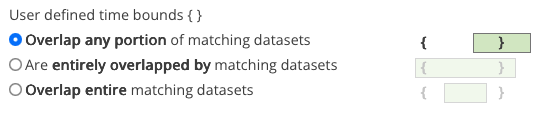

Let's look for datasets representing temperature within the Indo Pacific Warm Pool (10°S-10°N, 110°E-130°E) over the Holocene (0-10000 years BP):

In [20]:
ds = pt.NOAADataset()
res = ds.search_studies(variable_name = 'Temperature', earliest_year = 10000, latest_year=0, time_format = 'BP', min_lat = -10,
                        max_lat = 10, min_lon = 110, max_lon = 130, limit = 10)
display(res)

[2026-04-28 10:08:13,686][INFO] - search_studies: Limit set to 10.
[2026-04-28 10:08:13,686][INFO] - search_studies: Input Query includes geographical bounds. Inspect the results to ensure they match your intended region as one study can contain sites across various parts of the world.


Request URL: https://www.ncei.noaa.gov/access/paleo-search/study/search.json?dataPublisher=NOAA&limit=10&cvWhats=Temperature&minLat=-10&maxLat=10&minLon=110&maxLon=130&earliestYear=10000&latestYear=0&timeFormat=BP


Parsing NOAA studies: 100%|██████████| 10/10 [00:00<00:00, 4045.43it/s]
[2026-04-28 10:08:14,498][WARNING] - Retrieved 10 studies, which is the specified limit. Consider increasing the limit parameter to fetch more studies.
[2026-04-28 10:08:14,499][INFO] - Retrieved 10 studies.


,StudyID,XMLID,StudyName,DataType,EarliestYearBP,MostRecentYearBP,EarliestYearCE,MostRecentYearCE,"Coverage [S, N, W, E]",StudyNotes,ScienceKeywords,Investigators,Publications,Sites,Funding
0,10437,9101,"1,000 Year Ensemble Reconstructions of Tempera...",CLIMATE RECONSTRUCTIONS,950,-45,1000,1995,"(0.0, 90.0, -180.0, 180.0)",Calibration ensemble reconstructions of existi...,"[carbon cycle, sensitivity, Air Temperature Re...","David Frank, Jan Esper, Christoph Raible, Ulf ...","[{'Author': 'Frank, D.C., J. Esper, C.C. Raibl...","[[{'DataTableID': '19235', 'DataTableName': 'F...",[{'fundingAgency': 'Swiss National Science Fou...
1,8405,2665,Ammann and Wahl 2007 N. Hemisphere Temperature...,CLIMATE RECONSTRUCTIONS,950,-30,1000,1980,"(0.0, 80.0, -180.0, 180.0)",Northern hemisphere multiproxy average annual ...,[Air Temperature Reconstruction],"Caspar Ammann, Eugene Wahl","[{'Author': 'Ammann, C.M. and E.R. Wahl', 'Tit...","[[{'DataTableID': '19446', 'DataTableName': 'P...",[{'fundingAgency': 'US National Center for Atm...
2,40399,81483,"Antarctica Station Dome Concordia Chemistry, S...",ICE CORES,346462,500,-344512,1450,"(-90.0, 90.0, -180.0, 180.0)","Provided Keywords: ocean heat content, mean oc...","[Last Interglacial, Glacial, Interglacial, mil...","Markus Grimmer, Daniel Baggenstos, Jochen Schm...","[{'Author': 'Grimmer, Markus; Baggenstos, Dani...","[[{'DataTableID': '53967', 'DataTableName': 'E...",[{'fundingAgency': 'Swiss National Science Fou...
3,19523,17252,Asia 1200 Year Gridded Summer Temperature Reco...,CLIMATE RECONSTRUCTIONS,1150,-39,800,1989,"(-10.0, 54.0, 60.0, 148.0)",Tree-ring based 1200-year gridded (2x2 degree)...,"[PAGES Asia 2k, PAGES 2k Network, Air Temperat...","Edward Cook, Paul Krusic, Kevin Anchukaitis, B...","[{'Author': 'Edward R. Cook, Paul J. Krusic, K...","[[{'DataTableID': '30131', 'DataTableName': 'A...",[{'fundingAgency': 'US National Science Founda...
4,18635,16317,"Asian 1,100 Year Multiproxy Gridded Summer Tem...",CLIMATE RECONSTRUCTIONS,1050,-49,900,1999,"(2.5, 57.5, 62.5, 142.5)",Gridded and region-wide Asian summer (June-Jul...,"[PAGES Asia 2k, Air Temperature Reconstruction]","Feng Shi, Quansheng Ge, Bao Yang, Jianping Li,...","[{'Author': 'Feng Shi, Quansheng Ge, Bao Yang,...","[[{'DataTableID': '29014', 'DataTableName': 'S...",[{'fundingAgency': 'Chinese Academy of Science...
5,38539,79679,Asian Monsoon Region Speleothem Triple Oxygen ...,SPELEOTHEMS,217,-72,1733,2022,"(9.0, 40.0, 91.5, 118.5)",NaN,"[Other Reconstruction, hydrology, Monsoon]",Lijuan Sha,"[{'Author': 'Sha, Lijuan, Jasper A. Wassenburg...","[[{'DataTableID': '51200', 'DataTableName': 'A...",[{'fundingAgency': 'National Natural Science F...
6,33616,75234,Atmospheric CO2 66 Million Year Reconstruction...,CLIMATE FORCING,66000000,0,-65998050,1950,"(-90.0, 90.0, -180.0, 180.0)",Atmospheric carbon dioxide concentration recon...,[Atmospheric Gas Reconstruction],"James Rae, Yi Ge Zhang, Xiaoqing Liu, Gavin Fo...","[{'Author': 'James W.B. Rae, Yi Ge Zhang, Xiao...","[[{'DataTableID': '46636', 'DataTableName': 'R...",[]
7,12915,10980,Australasian Temperature Reconstructions Spann...,CLIMATE RECONSTRUCTIONS,950,-51,1000,2001,"(-50.0, 0.0, 110.0, 180.0)",Warm season (September-February) temperature r...,[Air Temperature Reconstruction],"Joëlle Gergis, Raphael Neukom, Ailie Gallant, ...","[{'Author': 'Joelle Gergis, Raphael Neukom, Ai...","[[{'DataTableID': '21257', 'DataTableName': 'G...",[{'fundingAgency': 'Australian Research Counci...
8,39727,80841,Bismarck Sea Geochemistry Data Over the Last 3...,PALEOCEANOGRAPHY,356440,670,-354490,1280,"(-80.0, 90.0, -180.0, 180.0)",International Ocean Discovery Program Expediti...,"[Last Glacial Maximum, Interglacial, biogeoche...","Vera Lawson, Yair Rosenthal, Samantha Bova, Ka...","[{'Author': 'Lisiecki, L.E. and M.E. Raymo', '...","[[{'DataTableID': '52768', 'DataTableName': 'B...","[{'fundingAgency': 'Vetlesen Foundation', 'fun..."
9,6224,2479,Briffa et al. 1998 Northern Hemisphere Tempera

By default, the search was done as `overAny`, including datasets that span much longer/shorter than the Holocene. Let's perform the search with `entireOver`, which requires the datasets to cover the entire time period, hence removing the shorter record:

In [23]:
res = ds.search_studies(variable_name = 'Temperature', earliest_year = 10000, latest_year=0, time_format = 'BP', min_lat = -10,
                        max_lat = 10, min_lon = 110, max_lon = 130, time_method = 'entireOver',limit = 10)
display(res)

[2026-04-28 10:49:55,057][INFO] - search_studies: Limit set to 10.
[2026-04-28 10:49:55,058][INFO] - search_studies: Input Query includes geographical bounds. Inspect the results to ensure they match your intended region as one study can contain sites across various parts of the world.


Request URL: https://www.ncei.noaa.gov/access/paleo-search/study/search.json?dataPublisher=NOAA&limit=10&cvWhats=Temperature&minLat=-10&maxLat=10&minLon=110&maxLon=130&earliestYear=10000&latestYear=0&timeFormat=BP&timeMethod=entireOver


Parsing NOAA studies: 100%|██████████| 10/10 [00:00<00:00, 6211.02it/s]
[2026-04-28 10:49:55,846][WARNING] - Retrieved 10 studies, which is the specified limit. Consider increasing the limit parameter to fetch more studies.
[2026-04-28 10:49:55,847][INFO] - Retrieved 10 studies.


,StudyID,XMLID,StudyName,DataType,EarliestYearBP,MostRecentYearBP,EarliestYearCE,MostRecentYearCE,"Coverage [S, N, W, E]",StudyNotes,ScienceKeywords,Investigators,Publications,Sites,Funding
0,33616,75234,Atmospheric CO2 66 Million Year Reconstruction...,CLIMATE FORCING,66000000,0,-65998050,1950,"(-90.0, 90.0, -180.0, 180.0)",Atmospheric carbon dioxide concentration recon...,[Atmospheric Gas Reconstruction],"James Rae, Yi Ge Zhang, Xiaoqing Liu, Gavin Fo...","[{'Author': 'James W.B. Rae, Yi Ge Zhang, Xiao...","[[{'DataTableID': '46636', 'DataTableName': 'R...",[]
1,5806,2523,CCM1 General Circulation Model Output,PALEOCLIMATIC MODELING,14000,0,-12050,1950,"(-90.0, 90.0, -180.0, 180.0)",NaN,None,"John Kutzbach, Pat Behling, Rich Selin","[{'Author': 'Wright, H.E., J.E. Kutzbach, T. W...","[[{'DataTableID': '32600', 'DataTableName': 'K...",[]
2,5807,2704,CCMO General Circulation Model Output Data Set,PALEOCLIMATIC MODELING,18000,0,-16050,1950,"(-90.0, 90.0, -180.0, 180.0)",NaN,None,"John Kutzbach, Pat Behling, Rich Selin, Peter ...","[{'Author': 'Wright, H.E., J.E. Kutzbach, T. W...","[[{'DataTableID': '32601', 'DataTableName': 'K...",[]
3,11932,10035,"Global 1Ma Temperature, Sea Level, and Ice Vol...",CLIMATE RECONSTRUCTIONS,1000000,0,-998050,1950,"(-90.0, 90.0, -180.0, 180.0)",Modelled reconstructions of surface air temper...,"[sea level, Sea Level Reconstruction, Air Temp...","Richard Bintanja, Roderik van de Wal, Johannes...","[{'Author': 'Bintanja, R., R.S.W. van de Wal, ...","[[{'DataTableID': '20412', 'DataTableName': 'B...",[{'fundingAgency': 'Netherlands Organization f...
4,11933,10036,"Global 3Ma Temperature, Sea Level, and Ice Vol...",CLIMATE RECONSTRUCTIONS,3000000,0,-2998050,1950,"(-90.0, 90.0, -180.0, 180.0)",A comprehensive ice-sheet model and a simple o...,"[Air Temperature Reconstruction, Sea Level Rec...","Richard Bintanja, Roderik van de Wal","[{'Author': 'Bintanja, R. and R.S.W. van de Wa...","[[{'DataTableID': '20413', 'DataTableName': 'B...",[{'fundingAgency': 'Netherlands Organization f...
5,38661,79820,Global 3Ma Transient CESM1.2 Climate Simulation,PALEOCLIMATIC MODELING,3000000,0,-2998050,1950,"(-90.0, 90.0, -180.0, 180.0)",Provided Keywords: ENSO; Monsoon; Last Glacial...,[Atmospheric and Oceanic Circulation Patterns ...,"Axel Timmermann, Kyung-Sook Yun","[{'Author': 'Yun, Kyung-Sook, Axel Timmermann,...","[[{'DataTableID': '51323', 'DataTableName': 'G...",[{'fundingAgency': 'Institute for Basic Scienc...
6,19564,17296,"Global 5 Million Year Sea Level, Temperature, ...",CLIMATE RECONSTRUCTIONS,5300000,0,-5298050,1950,"(-90.0, 90.0, -180.0, 180.0)",A coupled system of four ice-sheet models with...,"[Sea Level Reconstruction, Air Temperature Rec...","Bas de Boer, Lucas Lourens, Roderik van de Wal","[{'Author': 'B. de Boer, Lucas J. Lourens, and...","[[{'DataTableID': '30184', 'DataTableName': 'd...",[]
7,21210,19208,"Global 784,000 Year Proxy and Model Temperatur...",CLIMATE RECONSTRUCTIONS,783000,0,-781050,1950,"(-90.0, 90.0, -180.0, 180.0)",Globally-averaged Surface Air Temperature anom...,[Air Temperature Reconstruction],"Tobias Friedrich, Axel Timmermann, Michelle Ti...","[{'Author': 'Tobias Friedrich, Axel Timmermann...","[[{'DataTableID': '31984', 'DataTableName': 'F...",[{'fundingAgency': 'US National Science Founda...
8,29712,71572,Global Holocene Mean Surface Temperature Recon...,CLIMATE RECONSTRUCTIONS,12000,0,-10050,1950,"(-90.0, 90.0, -180.0, 180.0)",Global mean surface temperature (GMST) and ass...,[Air Temperature Reconstruction],"Darrell Kaufman, Nicholas McKay, Cody Routson,...","[{'Author': 'Darrell Kaufman, Nicholas McKay, ...","[[{'DataTableID': '42237', 'DataTableName': 'K...",[{'fundingAgency': 'US National Science Founda...
9,31572,73252,"Global Ocean 25,000 Year Atmosphere-Ocean CO2 ...",PALEOCLIMATIC MODELING,25000,0,-23050,1950,"(-80.0, 90.0, -180.0, 180.0)",Transient simulation of ocean carbonate chemis...,[carbon cycle],"Jun Shao, Lowell Stott, William Gray, Rosanna ...","[{'Autho

Similarly, using the `overEntire` will remove datasets that cover much longer timespans than the Holocene: 

In [24]:
res = ds.search_studies(variable_name = 'Temperature', earliest_year = 10000, latest_year=0, time_format = 'BP', min_lat = -10,
                        max_lat = 10, min_lon = 110, max_lon = 130, time_method = 'overEntire',limit = 10)
display(res)

[2026-04-28 10:51:10,592][INFO] - search_studies: Limit set to 10.
[2026-04-28 10:51:10,593][INFO] - search_studies: Input Query includes geographical bounds. Inspect the results to ensure they match your intended region as one study can contain sites across various parts of the world.


Request URL: https://www.ncei.noaa.gov/access/paleo-search/study/search.json?dataPublisher=NOAA&limit=10&cvWhats=Temperature&minLat=-10&maxLat=10&minLon=110&maxLon=130&earliestYear=10000&latestYear=0&timeFormat=BP&timeMethod=overEntire


Parsing NOAA studies: 100%|██████████| 9/9 [00:00<00:00, 6410.04it/s]
[2026-04-28 10:51:11,404][INFO] - Retrieved 9 studies.


,StudyID,XMLID,StudyName,DataType,EarliestYearBP,MostRecentYearBP,EarliestYearCE,MostRecentYearCE,"Coverage [S, N, W, E]",StudyNotes,ScienceKeywords,Investigators,Publications,Sites,Funding
0,27870,68450,Global Foraminifera Mg/Ca Surface Sediment Dat...,PALEOCEANOGRAPHY,100,0,1850,1950,"(-90.0, 90.0, -180.0, 180.0)",NaN,None,"Casey Saenger, Michael Evans","[{'Author': 'Saenger, Casey P. and Michael N. ...","[[{'DataTableID': '40237', 'DataTableName': 'G...",[{'fundingAgency': 'US National Science Founda...
1,30352,72053,Global Ocean Planktonic Foraminifera Boron Iso...,PALEOCEANOGRAPHY,300,200,1650,1750,"(-80.0, 90.0, -180.0, 180.0)",Core top foraminfera geochemical and boron iso...,None,"Maxence Guillermic, Sambuddha Misra, Robert Ea...","[{'Author': 'Maxence Guillermic, Sambuddha Mis...","[[{'DataTableID': '42860', 'DataTableName': 'G...",[]
2,18615,16297,Global TEX86 Surface Sediment Database,PALEOCEANOGRAPHY,100,0,1850,1950,"(-90.0, 90.0, -180.0, 180.0)",Global database of modern sediment observation...,None,"Jessica Tierney, Martin Tingley",[{'Author': 'Jessica E. Tierney and Martin P. ...,"[[{'DataTableID': '28994', 'DataTableName': 'T...",[]
3,5534,1725,Indo-Pacific Warm Pool (MD98-2160) Last Millen...,PALEOCEANOGRAPHY,871,0,1079,1950,"(-5.2, -5.2, 117.48, 117.48)",NaN,"[Other Hydroclimate Reconstruction, Sea Surfac...","Alicia Newton, Robert Thunell, Lowell Stott","[{'Author': 'Newton, A., R. Thunell, and L. St...","[[{'DataTableID': '7906', 'DataTableName': 'MD...",[]
4,8676,2758,"Langton et al. 2008 Kau Bay, Indonesia 3500-Ye...",PALEOCEANOGRAPHY,3500,0,-1550,1950,"(0.5, 0.5, 127.7167, 127.7167)",NaN,None,"Samantha Langton, Braddock Linsley, Rebecca Ro...","[{'Author': 'Langton, S.J., B.K. Linsley, R.S....","[[{'DataTableID': '32774', 'DataTableName': 'L...",[]
5,25890,64194,Northern Hemisphere Holocene Latitudinal Tempe...,CLIMATE RECONSTRUCTIONS,9900,100,-7950,1850,"(0.0, 90.0, -180.0, 180.0)",Composite latitude band (10S to 90N) temperatu...,[Air Temperature Reconstruction],"Cody Routson, Nicholas McKay, Darrell Kaufman,...","[{'Author': 'Cody C. Routson, Nicholas P. McKa...","[[{'DataTableID': '38833', 'DataTableName': 'R...",[]
6,26870,65819,Oceanic carbon-13 and nitrogen-15 isotopes sim...,PALEOCLIMATIC MODELING,100,0,1850,1950,"(-80.0, 90.0, -180.0, 180.0)",These simulations were run by Dr Pearse J Buch...,None,"Pearse Buchanan, Richard Matear, Zanna Chase, ...",[],"[[{'DataTableID': '39293', 'DataTableName': 'C...",[{'fundingAgency': 'Australian Research Counci...
7,8699,2729,"Oppo et al. 2009 Makassar Strait 2,000 Year SS...",PALEOCEANOGRAPHY,2315,-36,-365,1986,"(-5.2, 3.883333, 117.48, 119.45)",NaN,"[Other Hydroclimate Reconstruction, Sea Surfac...","Delia Oppo, Yair Rosenthal, Braddock Linsley","[{'Author': 'Oppo, D.W., Y. Rosenthal, and B.K...","[[{'DataTableID': '34916', 'DataTableName': 'M...",[]
8,16055,13818,Western Tropical Pacific SST and Isotope Data ...,PALEOCEANOGRAPHY,11031,199,-9081,1751,"(6.3, 6.3, 125.83, 125.83)",Benthic (Cibicicoides mundulus) foraminifera c...,None,"Deborah Khider, Charles Jackson, Lowell Stott","[{'Author': 'Stott, L.D., K.G. Cannariato, R.C...","[[{'DataTableID': '26023', 'DataTableName': 'M...",[{'fundingAgency': 'US National Science Founda...


## Summary

In this tutorial, you have learned how to use the `search_studies` function with its many parameters to perform query on NOAA NCEI for paleo. In the next tutorial, we will have a look at the PANGAEA search.